# NB-05 · Loss Function Diagnostics

**Checks covered**
1. Gaussian reconstruction: shape, non-negative amplitudes, finite values
2. Each loss term individually with synthetic batches
3. Gradient flow: `.backward()` on each term reaches model parameters
4. Gaussian matching strategies (`sorted_mu`, `sorted_a`, `sort_gt_by_mu`)
5. Degenerate cases: collapsed Gaussians, zero amplitudes, negative sigmas
6. Perfect prediction → loss ≈ 0; random prediction → loss >> 0
7. Loss scale sanity: all active terms within a similar order of magnitude

In [2]:
import sys, json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT    = Path("../..").resolve()
DATASET_PATH = Path("/ste/rnd/User/vice_vi/Dataset/clean_dataset")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tools.logger                   import Logger
from configuration.training_config  import GaussianConfig, LossConfig
from pipelines.training_pipeline.loss import Loss

logger = Logger(log_dir="/tmp", name="nb05")

# ── Gaussian config from dataset ─────────────────────────────────────────────
N_GAUSSIANS = 5
gaussian_cfg = GaussianConfig.from_dataset(DATASET_PATH, n_gaussians=N_GAUSSIANS)
print(f"x_min={gaussian_cfg.x_min:.2f}  x_max={gaussian_cfg.x_max:.2f}  N={N_GAUSSIANS}")

N_ELEV = 128
x_axis = torch.linspace(gaussian_cfg.x_min, gaussian_cfg.x_max, N_ELEV)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_axis = x_axis.to(DEVICE)
print(f"Device: {DEVICE}")

# ── Synthetic batch factory ───────────────────────────────────────────────────
B, H, W = 4, 32, 32
C       = N_GAUSSIANS * 3   # 15 channels (a, mu, sigma) × 5

def make_batch(perfect: bool = False, device=DEVICE):
    """Returns (pred_params, gt_params) of shape (B, C, H, W)."""
    torch.manual_seed(0)
    gt_a   = torch.rand(B, N_GAUSSIANS, H, W, device=device) * 2.0       # amp ≥ 0
    gt_mu  = torch.rand(B, N_GAUSSIANS, H, W, device=device) * (
        gaussian_cfg.x_max - gaussian_cfg.x_min) + gaussian_cfg.x_min    # within range
    gt_sig = torch.rand(B, N_GAUSSIANS, H, W, device=device) * 5.0 + 0.5 # sigma > 0
    gt     = torch.stack([gt_a, gt_mu, gt_sig], dim=2).reshape(B, C, H, W)

    if perfect:
        pred = gt.clone().detach().requires_grad_(True)
    else:
        pred = (gt + torch.randn_like(gt) * 0.5).detach().requires_grad_(True)

    return pred, gt

print("Batch shape:", make_batch()[0].shape)


x_min=-20.00  x_max=80.00  N=5
Device: cuda
Batch shape: torch.Size([4, 15, 32, 32])


## 1 · Gaussian reconstruction: shape & sanity

───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Field          ┃ Value     ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Sample points  │ 128       │
│ Param matching │ sorted_mu │
└────────────────┴───────────┘

               Active Terms                
┏━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Term      ┃ Alpha ┃ Norm     ┃ Eff      ┃
┡━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ mse_curve │ 1     │ 0.970732 │ 0.970732 │
└───────────┴───────┴──────────┴──────────┘

Curves shape : torch.Size([4, 128, 32, 32])  (expected B×N_ELEV×H×W = 4×128×32×32)
Finite values : True
Min value     : 0.0000  (should be ≥ 0 since relu applied to amp)
✓  All curve values non-negative


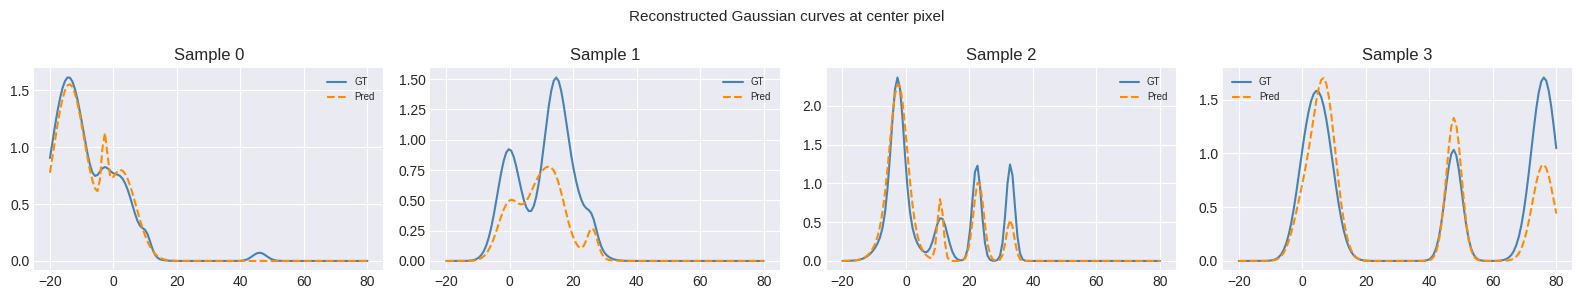

In [3]:
from tools.tracker import Tracker  # lightweight stub

loss_cfg = LossConfig(use_mse_curve=True, weight_mse_curve=1.0)
criterion = Loss(x_axis, logger, Tracker(writer=None), gaussian_cfg, loss_cfg)

pred, gt = make_batch()
curves   = criterion.reconstruct_gaussians(pred)

print(f"Curves shape : {curves.shape}  (expected B×N_ELEV×H×W = {B}×{N_ELEV}×{H}×{W})")
assert curves.shape == (B, N_ELEV, H, W), "⚠ Shape mismatch!"

print(f"Finite values : {torch.isfinite(curves).all().item()}")
print(f"Min value     : {curves.min().item():.4f}  (should be ≥ 0 since relu applied to amp)")
if curves.min().item() < -1e-6:
    print("⚠  Negative curve values – relu on amplitude may not be working")
else:
    print("✓  All curve values non-negative")

# Plot a few curves
x_np = x_axis.cpu().numpy()
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i in range(4):
    c_gt   = criterion.reconstruct_gaussians(gt)[i, :, H//2, W//2].detach().cpu().numpy()
    c_pred = curves[i, :, H//2, W//2].detach().cpu().numpy()
    axes[i].plot(x_np, c_gt,   label="GT",   color="steelblue")
    axes[i].plot(x_np, c_pred, label="Pred", color="darkorange", linestyle="--")
    axes[i].set_title(f"Sample {i}")
    axes[i].legend(fontsize=7)
plt.suptitle("Reconstructed Gaussian curves at center pixel", fontsize=11)
plt.tight_layout()
plt.show()

## 2 · Each loss term: value + gradient flow

In [4]:
from tools.tracker import Tracker

ALL_TERMS = [
    ("mse_curve",         dict(use_mse_curve=True,         weight_mse_curve=1.0)),
    ("l1_curve",          dict(use_l1_curve=True,          weight_l1_curve=1.0)),
    ("huber_curve",       dict(use_huber_curve=True,       weight_huber_curve=1.0)),
    ("charbonnier_curve", dict(use_charbonnier_curve=True, weight_charbonnier_curve=1.0)),
    ("cosine_curve",      dict(use_cosine_curve=True,      weight_cosine_curve=1.0)),
    ("ssim_curve",        dict(use_ssim_curve=True,        weight_ssim_curve=1.0)),
    ("param_l1",          dict(use_param_l1=True,          weight_param_l1=1.0)),
    ("param_huber",       dict(use_param_huber=True,       weight_param_huber=1.0)),
    ("smoothness_tv",     dict(use_smoothness_tv=True,     weight_smoothness_tv=1.0)),
]

results = []
print(f"  {'Term':<25s}  {'Value (rand)':>12s}  {'Value (perfect)':>15s}  {'Grad OK':>8s}  {'Issues'}")
print("  " + "-" * 80)

for term_name, kwargs in ALL_TERMS:
    cfg  = LossConfig(**kwargs)
    crit = Loss(x_axis, logger, Tracker(writer=None), gaussian_cfg, cfg)

    # Random prediction
    pred_r, gt_r = make_batch(perfect=False)
    out_r        = crit(pred_r, gt_r)
    loss_r       = out_r["total_loss"]
    val_r        = loss_r.item()

    # Perfect prediction
    pred_p, gt_p = make_batch(perfect=True)
    out_p        = crit(pred_p, gt_p)
    val_p        = out_p["total_loss"].item()

    # Gradient flow
    pred_g, gt_g = make_batch(perfect=False)
    out_g        = crit(pred_g, gt_g)
    out_g["total_loss"].backward()
    grad_ok = pred_g.grad is not None and torch.isfinite(pred_g.grad).all().item()

    issues = []
    if not torch.isfinite(loss_r): issues.append("non-finite")
    if val_p > val_r * 0.5:        issues.append("perf≈rand (not discriminative)")
    if val_r < 1e-9:               issues.append("value≈0 always")
    if not grad_ok:                issues.append("no/bad grad")

    flag = "✓" if not issues else "⚠"
    print(f"  {flag} {term_name:<23s}  {val_r:>12.4e}  {val_p:>15.4e}  {str(grad_ok):>8s}  {', '.join(issues)}")
    results.append((term_name, val_r, val_p, grad_ok))

  Term                       Value (rand)  Value (perfect)   Grad OK  Issues
  --------------------------------------------------------------------------------


───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Field          ┃ Value     ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Sample points  │ 128       │
│ Param matching │ sorted_mu │
└────────────────┴───────────┘

               Active Terms                
┏━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Term      ┃ Alpha ┃ Norm     ┃ Eff      ┃
┡━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ mse_curve │ 1     │ 0.970732 │ 0.970732 │
└───────────┴───────┴──────────┴──────────┘

  ✓ mse_curve                  6.8403e-02       0.0000e+00      True  


...

  ✓ param_huber                3.2298e-01       0.0000e+00      True  


───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Field          ┃ Value     ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Sample points  │ 128       │
│ Param matching │ sorted_mu │
└────────────────┴───────────┘

                Active Terms                 
┏━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Term          ┃ Alpha ┃ Norm    ┃ Eff     ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ smoothness_tv │ 1     │ 56.6549 │ 56.6549 │
└───────────────┴───────┴─────────┴─────────┘

  ⚠ smoothness_tv              1.3665e+03       1.3546e+03      True  perf≈rand (not discriminative)


## 3 · Gaussian matching strategies

In [5]:
strategies = ["sorted_mu", "sorted_a", "sort_gt_by_mu"]

print(f"  {'Strategy':<20s}  {'Loss value':>12s}  {'Grad OK':>8s}")
print("  " + "-" * 50)

for strat in strategies:
    cfg   = LossConfig(use_param_l1=True, weight_param_l1=1.0, param_match=strat)
    crit  = Loss(x_axis, logger, Tracker(writer=None), gaussian_cfg, cfg)
    pred, gt = make_batch(perfect=False)
    out  = crit(pred, gt)
    loss = out["total_loss"]
    loss.backward()
    grad_ok = pred.grad is not None and torch.isfinite(pred.grad).all().item()
    print(f"  {strat:<20s}  {loss.item():>12.4e}  {str(grad_ok):>8s}")

  Strategy                Loss value   Grad OK
  --------------------------------------------------


───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Field          ┃ Value     ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Sample points  │ 128       │
│ Param matching │ sorted_mu │
└────────────────┴───────────┘

          Active Terms           
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━┓
┃ Term     ┃ Alpha ┃ Norm ┃ Eff ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━┩
│ param_l1 │ 1     │ 1    │ 1   │
└──────────┴───────┴──────┴─────┘

  sorted_mu               4.1036e-01      True


...

  sorted_a                6.7466e+00      True


───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Field          ┃ Value         ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Sample points  │ 128           │
│ Param matching │ sort_gt_by_mu │
└────────────────┴───────────────┘

          Active Terms           
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━┓
┃ Term     ┃ Alpha ┃ Norm ┃ Eff ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━┩
│ param_l1 │ 1     │ 1    │ 1   │
└──────────┴───────┴──────┴─────┘

  sort_gt_by_mu           9.6049e+00      True


## 4 · Degenerate cases

In [6]:
cfg  = LossConfig(use_mse_curve=True, weight_mse_curve=1.0, use_param_l1=True, weight_param_l1=1.0)
crit = Loss(x_axis, logger, Tracker(writer=None), gaussian_cfg, cfg)

def test_case(label, pred_tensor, gt_tensor):
    try:
        out  = crit(pred_tensor, gt_tensor)
        loss = out["total_loss"]
        loss.backward()
        grad_ok = pred_tensor.grad is not None and torch.isfinite(pred_tensor.grad).all().item()
        finite  = torch.isfinite(loss).item()
        flag    = "✓" if (finite and grad_ok) else "⚠"
        print(f"  {flag} {label:<35s}  loss={loss.item():.4e}  finite={finite}  grad_ok={grad_ok}")
    except Exception as e:
        print(f"  ✗ {label:<35s}  EXCEPTION: {e}")

# Case 1: all-zero amplitudes
pred_z, gt_z = make_batch()
pred_z_mod   = pred_z.detach().clone()
pred_z_mod[:, 0::3] = 0.0   # all amplitude channels = 0
pred_z_mod   = pred_z_mod.requires_grad_(True)
test_case("All-zero predicted amplitudes", pred_z_mod, gt_z)

# Case 2: negative sigma
pred_ns, gt_ns = make_batch()
pred_ns_mod    = pred_ns.detach().clone()
pred_ns_mod[:, 2::3] = -5.0   # all sigma channels = -5
pred_ns_mod    = pred_ns_mod.requires_grad_(True)
test_case("Negative predicted sigma", pred_ns_mod, gt_ns)

# Case 3: very large amplitudes (potential overflow)
pred_la, gt_la = make_batch()
pred_la_mod    = pred_la.detach().clone() * 1000.0
pred_la_mod    = pred_la_mod.requires_grad_(True)
test_case("Very large amplitudes (×1000)", pred_la_mod, gt_la)

# Case 4: GT all-zero (inactive Gaussians)
pred_ag, gt_ag = make_batch()
gt_all_zero    = torch.zeros_like(gt_ag)
test_case("GT all-zero (all inactive)",  pred_ag, gt_all_zero)

# Case 5: NaN in prediction (should propagate, not crash)
pred_nan, gt_nan = make_batch()
pred_nan_mod     = pred_nan.detach().clone()
pred_nan_mod[0, 0, 0, 0] = float('nan')
pred_nan_mod     = pred_nan_mod.requires_grad_(True)
test_case("Single NaN in prediction",    pred_nan_mod, gt_nan)

───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Field          ┃ Value     ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Sample points  │ 128       │
│ Param matching │ sorted_mu │
└────────────────┴───────────┘

               Active Terms                
┏━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Term      ┃ Alpha ┃ Norm     ┃ Eff      ┃
┡━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ mse_curve │ 1     │ 0.970732 │ 0.970732 │
│ param_l1  │ 1     │ 1        │ 1        │
└───────────┴───────┴──────────┴──────────┘

  ✓ All-zero predicted amplitudes        loss=1.0448e+00  finite=True  grad_ok=True
  ✓ Negative predicted sigma             loss=3.2049e+00  finite=True  grad_ok=True
  ✓ Very large amplitudes (×1000)        loss=5.4798e+05  finite=True  grad_ok=True
  ✓ GT all-zero (all inactive)           loss=1.3154e+01  finite=True  grad_ok=True
  ⚠ Single NaN in prediction             loss=nan  finite=False  grad_ok=False


## 5 · Loss scale comparison (all terms on same batch)

───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Field          ┃ Value     ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Sample points  │ 128       │
│ Param matching │ sorted_mu │
└────────────────┴───────────┘

               Active Terms                
┏━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Term      ┃ Alpha ┃ Norm     ┃ Eff      ┃
┡━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ mse_curve │ 1     │ 0.970732 │ 0.970732 │
└───────────┴───────┴──────────┴──────────┘

───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Field          ┃ Value     ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Sample points  │ 128       │
│ Param matching │ sorted_mu │
└────────────────┴───────────┘

...

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Field          ┃ Value     ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Sample points  │ 128       │
│ Param matching │ sorted_mu │
└────────────────┴───────────┘

               Active Terms                
┏━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Term        ┃ Alpha ┃ Norm    ┃ Eff     ┃
┡━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ param_huber │ 1     │ 2.89342 │ 2.89342 │
└─────────────┴───────┴─────────┴─────────┘

───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Field          ┃ Value     ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Sample points  │ 128       │
│ Param matching │ sorted_mu │
└────────────────┴───────────┘

                Active Terms                 
┏━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Term          ┃ Alpha ┃ Norm    ┃ Eff     ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ smoothness_tv │ 1     │ 56.6549 │ 56.6549 │
└───────────────┴───────┴─────────┴─────────┘

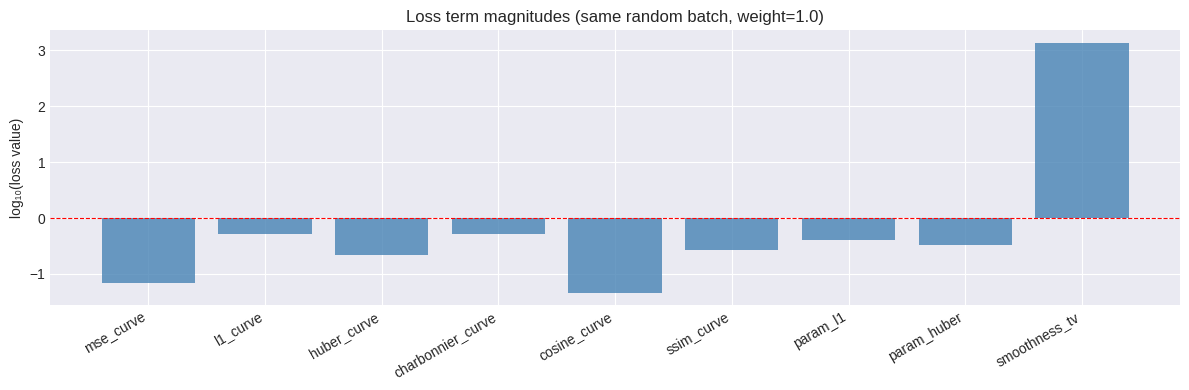

Raw values:
  mse_curve                : 6.8403e-02
  l1_curve                 : 5.1840e-01
  huber_curve              : 2.1898e-01
  charbonnier_curve        : 5.1720e-01
  cosine_curve             : 4.6137e-02
  ssim_curve               : 2.6403e-01
  param_l1                 : 4.1036e-01
  param_huber              : 3.2298e-01
  smoothness_tv            : 1.3665e+03


In [7]:
pred_s, gt_s = make_batch(perfect=False)

scale_data = []
for term_name, kwargs in ALL_TERMS:
    cfg  = LossConfig(**kwargs)
    crit = Loss(x_axis, logger, Tracker(writer=None), gaussian_cfg, cfg)
    with torch.no_grad():
        out = crit(pred_s.detach(), gt_s)
    scale_data.append((term_name, out["total_loss"].item()))

names  = [d[0]  for d in scale_data]
values = [d[1]  for d in scale_data]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(names, np.log10(np.clip(values, 1e-12, None)), color="steelblue", alpha=0.8)
ax.set_ylabel("log₁₀(loss value)")
ax.set_title("Loss term magnitudes (same random batch, weight=1.0)")
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Raw values:")
for name, val in scale_data:
    print(f"  {name:<25s}: {val:.4e}")

## 6 · Combined loss (as in train.py)

In [8]:
train_cfg = LossConfig(
    use_param_l1   = True,  weight_param_l1   = 1.0,
    param_match    = "sort_gt_by_mu",
)
crit_train = Loss(x_axis, logger, Tracker(writer=None), gaussian_cfg, train_cfg)

pred_t, gt_t = make_batch(perfect=False)
out_t        = crit_train(pred_t, gt_t)
out_t["total_loss"].backward()

print("Combined loss breakdown:")
for k, v in out_t["weighted"].items():
    print(f"  {k:<30s}: {v.item():.4e}")
print(f"\n  {'total_loss':<30s}: {out_t['total_loss'].item():.4e}")
print(f"  Gradient norm on pred : {pred_t.grad.norm().item():.4e}")
print(f"  Grad finite?          : {torch.isfinite(pred_t.grad).all().item()}")

───────────────────────────────────────────────── [LOSS FUNCTION] ─────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Field          ┃ Value         ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Sample points  │ 128           │
│ Param matching │ sort_gt_by_mu │
└────────────────┴───────────────┘

          Active Terms           
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━┓
┃ Term     ┃ Alpha ┃ Norm ┃ Eff ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━┩
│ param_l1 │ 1     │ 1    │ 1   │
└──────────┴───────┴──────┴─────┘

Combined loss breakdown:
  param_l1                      : 9.6049e+00
  param_l1/amp                  : 7.0125e-01
  param_l1/mu                   : 2.6661e+01
  param_l1/sigma                : 1.4527e+00

  total_loss                    : 9.6049e+00
  Gradient norm on pred : 4.0344e-03
  Grad finite?          : True
